In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
from src.io_utils import load_csv, coerce_numeric
from src.health_class import HealthAnalyser
from src.class_plot import HealthPlot
from statsmodels.stats.power import TTestIndPower



df = coerce_numeric(load_csv("data/hsd.csv"))



In [3]:
from src.metrics import information

print(information(df))


             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


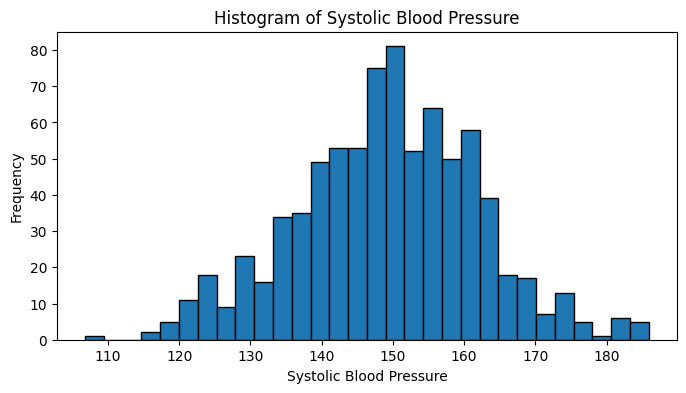

None


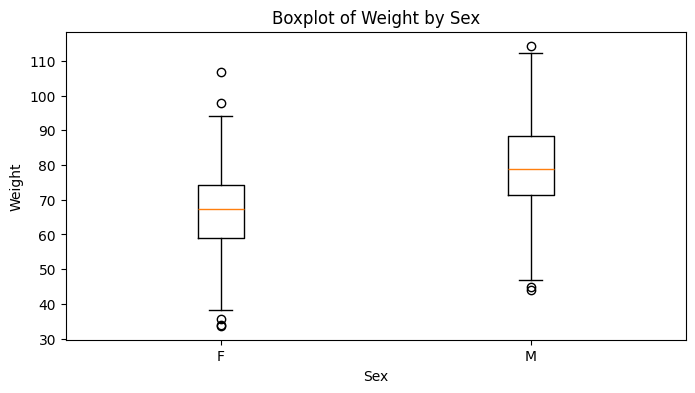

None


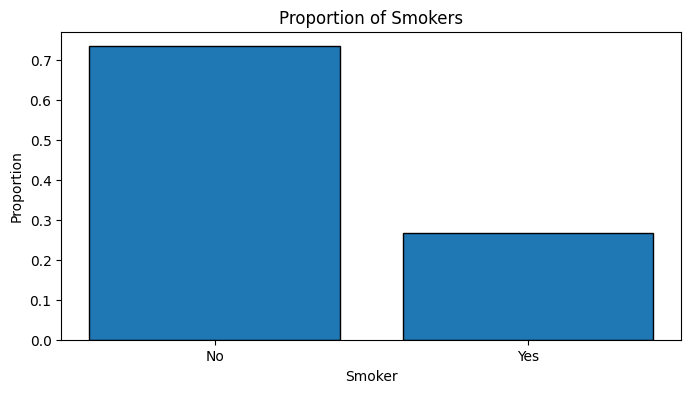

None


In [4]:
health = HealthAnalyser(df)

print(health.hist_bloodpressure())
print(health.box_weight_sex())
print(health.bar_smokers())

In [5]:
np.random.seed(123)
health.sim_disease()


Verklig andel: 0.059
Simulerad andel: 0.066
Skillnad: 0.007


Konfidens intervall av blodtrycket

In [6]:
health.connfidence_interval("systolic_bp")

'CL low 148.29, CL high 150.07'

Hypotes prövning "Rökare har högre medel-blodtryck än icke-rökare.”

In [7]:
health.blood_pressure_smoker_vs_nonesmoker()

't -score 0.45, p value 0.33'

Testet ger ett p-värde på 0.326, viket innebär att det är ungefär 33% chans att vi ser prov som har sådan här skillnad eller mer.
Jag använde mig av ett 95% konfidensintervall viket betyder att jag misslykades att avvisa noll_hypotesen efersom p värdet var större än alpha 0.05.
Det finns inte tillräckligt med stöd för att säga att det finns en skillnad.

Räknar ut power 

In [8]:
from src.metrics import smoker_power_analysis
power = smoker_power_analysis(df)

print(power)

power : 0.07461138937273196


som vi kan se har jag bara en 7.5% chans att upptäcka en skillnad i systolic BP mellan rökare och ickerökare. Man brukar sätta gränsen vid 80% power viket vi ligger långt under 

In [9]:
import pandas as pd
import numpy as np
from scipy import stats

smokers = df[df["smoker"] == "Yes"]["systolic_bp"].dropna().values
nonsmokers = df[df["smoker"] == "No"]["systolic_bp"].dropna().values

n_s  = len(smokers)
n_ns = len(nonsmokers)
var_s  = np.var(smokers, ddof=1)
var_ns = np.var(nonsmokers, ddof=1)

print("Antal rökare:", n_s)
print("Antal icke-rökare:", n_ns)

def estimate_power(effect_mmHg, iters=2000, alpha=0.05):
 
    rng = np.random.default_rng()
    sig = 0
    base_mean = np.mean(nonsmokers) 

    for _ in range(iters):
        sim_ns = rng.normal(loc=base_mean, scale=np.sqrt(var_ns), size=n_ns)
        sim_s  = rng.normal(loc=base_mean + effect_mmHg, scale=np.sqrt(var_s),  size=n_s)
        t_stat, p_val = stats.ttest_ind(sim_s, sim_ns, equal_var=False, alternative="greater")

        if p_val < alpha:
            sig += 1

    return sig / iters

effects = [0, 1, 2, 3, 4, 5] 
powers = [estimate_power(e) for e in effects]

for e, p in zip(effects, powers):
    print(f"Sann skillnad = {e:>2} mmHg  ->  power ≈ {p:.3f}")

Antal rökare: 213
Antal icke-rökare: 587


Sann skillnad =  0 mmHg  ->  power ≈ 0.052
Sann skillnad =  1 mmHg  ->  power ≈ 0.234
Sann skillnad =  2 mmHg  ->  power ≈ 0.605
Sann skillnad =  3 mmHg  ->  power ≈ 0.896
Sann skillnad =  4 mmHg  ->  power ≈ 0.988
Sann skillnad =  5 mmHg  ->  power ≈ 1.000


Vi börjar med att definiera två normalfördelningar som representerar de två populationerna (t.ex. rökare och icke-rökare), där båda har sina respektive standardavvikelser från den riktiga datan. Den ena populationen har ett medelvärde som är 3 mmHg högre än den andra för att motsvara den antagna sanna effekten.
Från dessa två fördelningar drar vi sedan slumpmässiga stickprov av storlek n och genomför ett Welch’s tvåstickprovstest (ttest_ind med equal_var=False). För varje iteration får vi ett t-värde och ett p-värde.
Denna process upprepas 2000 gånger. Efteråt räknar vi hur stor andel av simuleringarna som ger ett p-värde under 0,05, vilket innebär att nollhypotesen (ingen skillnad mellan grupperna) förkastas. Denna andel är en uppskattning av testets power, det vill säga sannolikheten att upptäcka en verklig skillnad på 3 mmHg givet stickprovsstorlekarna och variansen i datan.
I våra simuleringar ser vi att en sann skillnad på 3 mmHg skulle ge en power på cirka 80 %, vilket ofta används som en riktlinje för att en studie ska ha tillräcklig styrka för att kunna påvisa en effekt och därmed kunna förkasta nollhypotesen.

I vårt faktiska datamaterial uppskattas däremot powern till endast omkring 3,7 %. Detta är mycket lågt och innebär att studien har liten sannolikhet att upptäcka en eventuell verklig skillnad. Vi kan därför inte förkasta nollhypotesen, och den observerade skillnaden kan mycket väl bero på slumpen.

Detta är en linjär regression med två parametrar 

In [10]:
from src.metrics import linear_model

linreg, x, y, r2 = linear_model(df, ["age", "weight"])



intercept: 109.499
slope (weight): 0.539
R²: 0.405


Detta är med en parameter samt en graf av värdena 

intercept: 122.685
slope (weight): 0.536
R²: 0.369


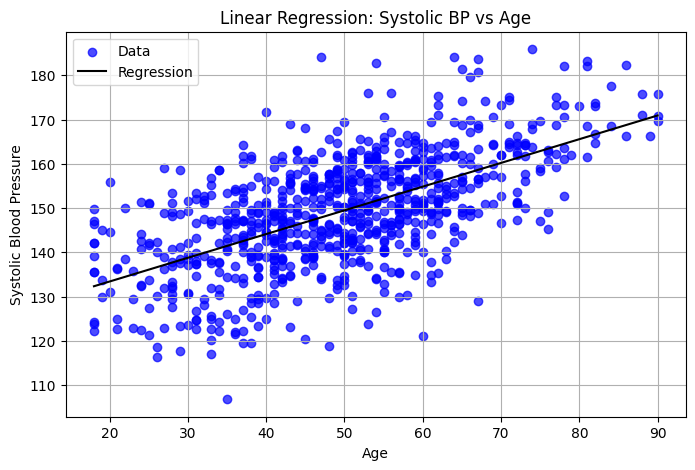

In [27]:
from src.plot_fig import plot_regression

linreg, x, y, r2 = linear_model(df, ["age"])

plot_regression(x, y , linreg)

vi kan se att ungefär 37 % av variationen i blodtryck kan förklaras av ålder och ca 41 % när vi anväder både ålder och vikt

försökte mig på PCA men förstod inte helt hur man gjorde, förstår att man vill reducera antalet dimensioner på sin data för att kunna förstå den bättre men fattar inte riktigt koden bakom det.

In [12]:
import seaborn as sns

In [13]:

df = coerce_numeric(load_csv("data/hsd.csv"))


In [14]:
df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression

X = df[['height', 'weight', 'cholesterol']]
y = df['systolic_bp']


model = LinearRegression()
model.fit(X, y)
r2 = float(linreg.score(x, y))

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R2: ",{r2})

Coefficients: [0.1068342  0.05796722 5.36973061]
Intercept: 100.09549293909004
R2:  {0.36915159840526035}


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB
